# Figure 1 Jupyter Notebook

This file produces the measured cavity data for figure 1 (specifically resonances and coupling)

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
from scipy.constants import c

from lmfit import Model, Parameters
from lmfit.models import ConstantModel, BreitWignerModel

In [2]:
# data params
DATA_DIR = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Unmounted_device_mk_3/2026_04_15/cavity_scan/device_36')
CSV_PATH = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Unmounted_device_mk_3/2026_04_15/cavity_scan/device_36/resonance_freq_data.csv')
LASER_OFF_PATH = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                  '/Unmounted_device_mk_3/2026_04_15/cavity_scan/device_36/LASEROFF.csv')
signal_file = 29
pump_file = 16
idler_file = 3

center_guess = 15
amp_guess = 2
c_guess = 0.5
q_guess = 0

# read laser offres data
laser_off_df = pd.read_csv(LASER_OFF_PATH, header=10, skiprows=[11])
zero_level = np.mean(laser_off_df['CH1'].astype(float))


# read main csv
main_df = pd.read_csv(CSV_PATH)
num_files = len(main_df['File'])

signal_freq = None
pump_freq = None
idler_freq = None
signal_trans = None
pump_trans = None
idler_trans = None

all_wl = []
all_trans = []

for _, row in main_df.iterrows():
    file_num = row['File'].astype(int)
    min_freq = row['Minimum (GHz)']
    max_freq = row['Maximum (GHz)']

    data_path = os.path.join(DATA_DIR, f'data_{file_num:06}.csv')
    data_df = pd.read_csv(data_path)

    ramp = data_df['Ramp Voltage (V)'].astype(float)
    transmission = data_df['Data Voltage (V)'].astype(float)
    transmission -= zero_level

    id_min = np.argmin(ramp)
    id_max = np.argmax(ramp)
    transmission = transmission[id_min:id_max]
    transmission.reset_index(drop=True, inplace=True)
    freq = np.linspace(min_freq/1e3, max_freq/1e3,
                       num=(id_max - id_min))  # unit: THz
    wl = c / freq
    wl /= 1e3  # convert to nm

    # plot this row individually if requested
    if file_num == signal_file:
        signal_freq = freq
        signal_trans = transmission
    elif file_num == pump_file:
        pump_freq = freq
        pump_trans = transmission
    elif file_num == idler_file:
        idler_freq = freq
        idler_trans = transmission

    # plot transmission (as dB if requested)
    all_wl.append(wl)
    all_trans.append(transmission)

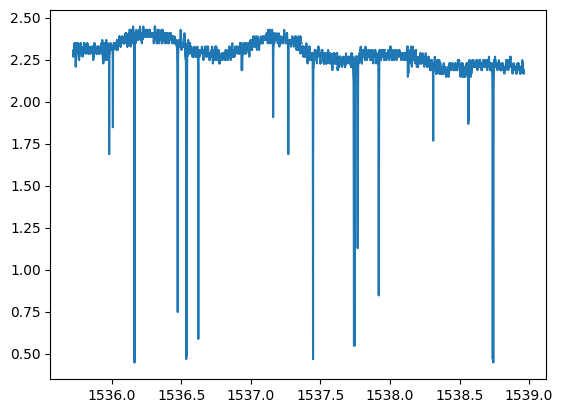

In [3]:
fig, ax = plt.subplots()

for i, (wl, trans) in enumerate(zip(all_wl, all_trans)):
    if i % 2 == 0:
        ax.plot(wl, trans, color='tab:blue')

Fitting Signal resonance
[[Model]]
    (Model(breit_wigner) + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 406
    # data points      = 4987
    # variables        = 5
    chi-square         = 1.67290043
    reduced chi-square = 3.3579e-04
    Akaike info crit   = -39886.1541
    Bayesian info crit = -39853.5811
    R-squared          = 0.97279046
[[Variables]]
    amplitude: -9.6885e-04 +/- 1.4016e-04 (14.47%) (init = 2)
    center:     16.1232332 +/- 3.4749e-04 (0.00%) (init = 15)
    sigma:      0.14728948 +/- 6.9801e-04 (0.47%) (init = 1)
    q:          43.2184604 +/- 3.12709255 (7.24%) (init = 0)
    c:          2.22132602 +/- 2.9689e-04 (0.01%) (init = 0.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(amplitude, q)      = +0.9997
    C(center, q)         = +0.7093
    C(amplitude, center) = +0.7091
    C(amplitude, c)      = -0.4616
    C(q, c)              = -0.4615
    C(center, c)         = -0.3274
    C(sigma, 

/var/folders/9s/1vly09jx3z36sfxgrw8bfrf80000gn/T/ipykernel_5982/1383936026.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[[Model]]
    (Model(breit_wigner) + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7900
    # data points      = 4985
    # variables        = 5
    chi-square         = 6.96062785
    reduced chi-square = 0.00139772
    Akaike info crit   = -32760.9862
    Bayesian info crit = -32728.4153
    R-squared          = 0.92386874
[[Variables]]
    amplitude: -1.4250e-11 +/- 3.1305e-08 (219673.49%) (init = 2)
    center:     13.1920751 +/- 6.4310e-04 (0.00%) (init = 15)
    sigma:      0.15881283 +/- 0.00129211 (0.81%) (init = 1)
    q:         -381752.112 +/- 4.1754e+08 (109373.82%) (init = 0)
    c:          2.38126387 +/- 5.3815e-04 (0.02%) (init = 0.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(amplitude, q)      = -1.0000
    C(amplitude, center) = -0.7095
    C(center, q)         = +0.7095
    C(sigma, c)          = +0.1262
Cavity kappa: 0.159 GHz
Cavity freq: 195156.985 GHz
Cavity q: 1228848.990


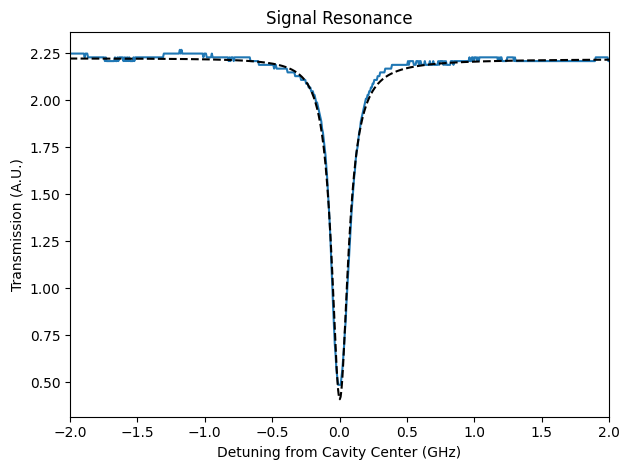

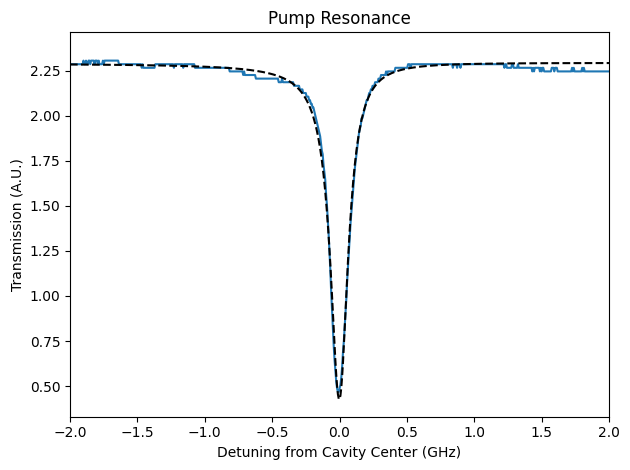

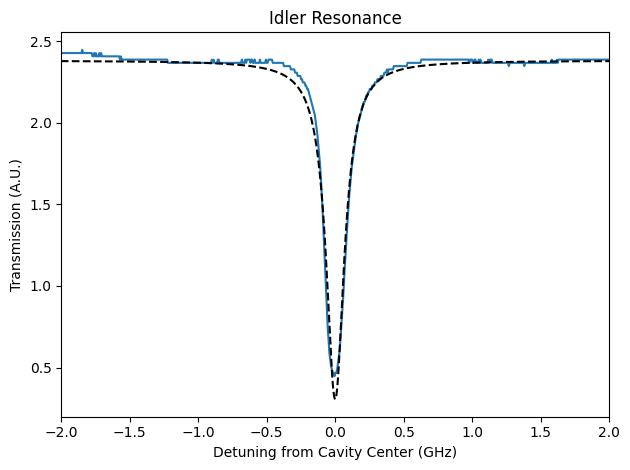

In [4]:
def resonance_helper(freq, trans, center=center_guess, amplitude=amp_guess, c=c_guess, q=q_guess, print_report=False):
    ref_freq = min(freq)
    freq -= ref_freq  # set to detuning in THz
    freq *= 1e3  # convert to GHz
    ref_freq *= 1e3
    model = BreitWignerModel() + ConstantModel()
    res = model.fit(trans, x=freq,
                    center=center, amplitude=amplitude, c=c, q=q)
    # set freq to be detuning from cavity center
    freq -= res.params['center'].value

    if print_report:
        print(res.fit_report())
        cavity_kappa = res.params['sigma'].value
        cavity_freq = ref_freq + res.params['center'].value
        cavity_q = cavity_freq / cavity_kappa
        print(f'Cavity kappa: {cavity_kappa:.3f} GHz')
        print(f'Cavity freq: {cavity_freq:.3f} GHz')
        print(f'Cavity q: {cavity_q:.3f}')

    return res, freq

# fitting and plotting of selected files
labels = ['Signal', 'Pump', 'Idler']
individual_res = []
for freq, trans, label in zip([signal_freq, pump_freq, idler_freq],
                              [signal_trans, pump_trans, idler_trans],
                              labels):
    print(f'Fitting {label} resonance')
    res, freq_detuning = resonance_helper(freq, trans, print_report=True)
    individual_res.append(res)

    fig, ax = plt.subplots()
    ax.plot(freq_detuning, trans)
    ax.plot(freq_detuning, res.best_fit, '--k')
    ax.set_xlim(-2, 2)
    ax.set_title(f'{label} Resonance')
    ax.set_xlabel('Detuning from Cavity Center (GHz)')
    ax.set_ylabel('Transmission (A.U.)')

    fig.tight_layout()
    fig.show()

## Subfigure for Coupling

In [5]:
DATA = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
        '/Mounted_device_mk_5/10mK/2026_04_14/cavity_field_scan/cavity_scan_1238mT.txt')
DATA_NO_IONS = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                '/Mounted_device_mk_5/10mK/2026_04_14/cavity_field_scan/cavity_scan_0598mT.txt')
FREQ_START = 194824.878
FREQ_END = 194833.854

# plotting params
# XLIM = (2, 7)  # unit: GHz
XLIM_range = 6.5  # unit: GHz
color_ion = 'coral'
color_no_ion = 'cornflowerblue'

# fitting guesses
# frequency parameters
w_cav_guess = 4.2
w_ion_guess = 4.3

# cavity parameters
kappa_guess = 0.433

# coupling parameters
coupling_guess = 0.25  # unit: GHz
inhomog_guess = 0.3  # unit: GHz

# fitting function
def R_mod_lmfit(x, w_cav, w_ions, kappa, kappa_in, coupling, inhomog, a):
    ion_term = (coupling ** 2) / (x - w_ions + 1j * inhomog / 2)
    t = 1 - (1j*kappa_in)/(x - w_cav + 1j * kappa / 2 - ion_term)
    return a * (np.abs(t) ** 2)

In [6]:
# read data and fit
df = pd.read_csv(DATA, sep='\t')
transmission_ions = df['counts']
time = df['time(ps)']
freq = np.linspace(0, FREQ_END-FREQ_START, len(time))

df_no_ions = pd.read_csv(DATA_NO_IONS, sep='\t')
transmission_no_ions = df_no_ions['counts']

# fitting of data

# fit no ion cavity to extract cavity data
model_cavity = BreitWignerModel() + ConstantModel()
res_cavity = model_cavity.fit(transmission_no_ions, x=freq,
                              center=w_cav_guess,
                              sigma=kappa_guess,
                              q=0,
                              amplitude=max(transmission_no_ions))
fitted_kappa = res_cavity.params['sigma'].value
fitted_w_cav = res_cavity.params['center'].value
kappa_in_guess = fitted_kappa / 2
reflection = res_cavity.params['c'].value / (res_cavity.params['c'].value + res_cavity.params['amplitude'].value)
fitted_kappa_in = (fitted_kappa / 2) * (1 + np.sqrt(reflection))
print(f"Fitted kappa: {fitted_kappa:.3f} GHz")
print(f"Fitted w_cav: {fitted_w_cav:.3f} GHz")
print(f"Reflection: {reflection:.3f}")
print(f"Fitted kappa_in: {fitted_kappa_in:.3f} GHz")

model = Model(R_mod_lmfit)
params = Parameters()
params.add('w_cav', value=fitted_w_cav)
params.add('w_ions', value=w_ion_guess)
params.add('kappa', value=fitted_kappa, vary=False)
params.add('kappa_in', value=fitted_kappa_in, vary=False)
params.add('coupling', value=coupling_guess)
params.add('inhomog', value=inhomog_guess)
params.add('a', value=max(transmission_ions))
res = model.fit(transmission_ions, params, x=freq)

Fitted kappa: 0.396 GHz
Fitted w_cav: 4.284 GHz
Reflection: 0.025
Fitted kappa_in: 0.229 GHz


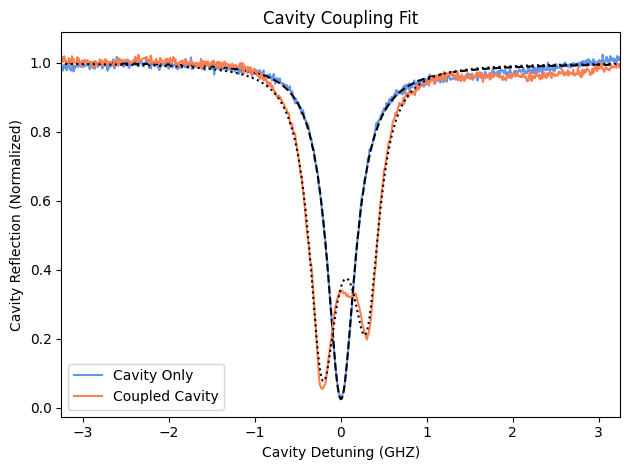

In [7]:
# plotting
norm_factor_no_ions = res_cavity.params['amplitude'].value + res_cavity.params['c'].value
norm_factor = res.params['a'].value
freq_centered_no_ions = freq - res_cavity.params['center'].value
freq_centered = freq - res.params['w_cav'].value

fig, ax = plt.subplots()
plt.plot(freq_centered_no_ions, transmission_no_ions/norm_factor_no_ions,
         color=color_no_ion, label='Cavity Only')
plt.plot(freq_centered_no_ions, res_cavity.best_fit/norm_factor_no_ions,
         ls='--', color='k')
plt.plot(freq_centered, transmission_ions/norm_factor,
         color=color_ion, label='Coupled Cavity')
plt.plot(freq_centered, res.best_fit/norm_factor,
         ls=':', color='k')
plt.xlabel(f'Cavity Detuning (GHZ)')
plt.ylabel('Cavity Reflection (Normalized)')
plt.title('Cavity Coupling Fit')
plt.xlim(-XLIM_range/2, XLIM_range/2)
# plt.ylim(0, 30000)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# print reports
print(res_cavity.fit_report())
print(res.fit_report())

coupling = res.params['coupling'].value
coupling_err = res.params['coupling'].stderr
inhomog = res.params['inhomog'].value
inhomog_err = res.params['inhomog'].stderr
kappa = res_cavity.params['sigma'].value
kappa_err = res_cavity.params['sigma'].stderr

coop = (4 * (coupling ** 2)) / (kappa * inhomog)
coop_err = coop * np.sqrt((2*coupling_err/coupling)**2 + (inhomog_err/inhomog)**2 + (kappa_err/kappa)**2)
print(f'Fitted cooperativity: {coop:.3f} +/- {coop_err:.3f}')

print(f'Fitted center of cavity: {res.params["w_cav"].value+FREQ_START:.3f} GHz')

[[Model]]
    (Model(breit_wigner) + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 31
    # data points      = 1000
    # variables        = 5
    chi-square         = 80489344.9
    reduced chi-square = 80893.8139
    Akaike info crit   = 11305.8801
    Bayesian info crit = 11330.4189
    R-squared          = 0.99408395
[[Variables]]
    amplitude:  21196.0046 +/- 68.3688332 (0.32%) (init = 22546)
    center:     4.28378081 +/- 9.3063e-04 (0.02%) (init = 4.2)
    sigma:      0.39595193 +/- 0.00194025 (0.49%) (init = 0.433)
    q:         -0.02105192 +/- 0.00171138 (8.13%) (init = 0)
    c:          544.426568 +/- 68.9755928 (12.67%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(amplitude, c)     = -0.9886
    C(center, q)        = +0.7277
    C(sigma, c)         = +0.7009
    C(amplitude, sigma) = -0.6517
[[Model]]
    Model(R_mod_lmfit)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   

# Main Plot Code

In [20]:
# matplotlib general (and font)
mpl.rcParams.update({'font.sans-serif': 'Arial',
                     'font.size': 8})
figsize = (6, 2)  # inches
dpi = 100
include_subplot_titles = False

# colors
color_primary = '#7570b3'
color_secondary = '#d95f02'
color_tertiary = '#1b9e77'

# figure layout
vertical_ratios = (1, 1)
horizontal_ratios = (4, 2)
horizontal_ratios_resonance = (1, 1, 1)
vertical_padding = 0.02
horizontal_padding = 0.02

Text(0.02, 0.5, 'Reflection (A.U.)')

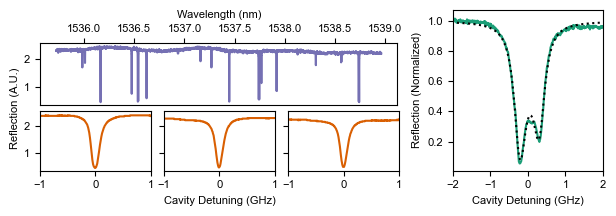

In [52]:
fig = plt.figure(layout='constrained', figsize=figsize, dpi=dpi)
fig.get_layout_engine().set(w_pad=horizontal_padding, h_pad=vertical_padding)
subfigs = fig.subfigures(1, 2, width_ratios=horizontal_ratios)
subfigs_resonance = subfigs[0].subfigures(2, 1, height_ratios=vertical_ratios)
ax_wide = subfigs_resonance[0].subplots()
ax_individual = subfigs_resonance[1].subplots(1, 3, width_ratios=horizontal_ratios_resonance, sharey=True)
ax_coupling = subfigs[1].subplots()

for i, (wl, trans) in enumerate(zip(all_wl, all_trans)):
    if i % 2 == 0:
        ax_wide.plot(wl, trans, color=color_primary)
ax_wide.set_xlabel('Wavelength (nm)')
ax_wide.xaxis.set_tick_params(labeltop=True,
                              labelbottom=False,
                              top=True,
                              bottom=False)
ax_wide.xaxis.set_label_position('top')

ax_individual[0].plot(idler_freq, idler_trans, color=color_secondary)
ax_individual[0].set_xlim(-1, 1)

ax_individual[1].plot(pump_freq, pump_trans, color=color_secondary)
ax_individual[1].set_xlim(-1, 1)
ax_individual[1].set_xlabel('Cavity Detuning (GHz)')

ax_individual[2].plot(signal_freq, signal_trans, color=color_secondary)
ax_individual[2].set_xlim(-1, 1)

ax_coupling.plot(freq_centered, transmission_ions/norm_factor,
                 color=color_tertiary)
ax_coupling.plot(freq_centered, res.best_fit/norm_factor,
                 ls=':', color='k')
ax_coupling.set_xlim(-2, 2)
ax_coupling.set_xlabel('Cavity Detuning (GHz)')
ax_coupling.set_ylabel('Reflection (Normalized)')

subfigs[0].supylabel('Reflection (A.U.)', fontsize=8)

In [53]:
fig.savefig('fig1.pdf')
os.getcwd()

'/Users/alexkolar/Desktop/Lab/lab-plotting/ring_resonators/paper_figures'